In [ ]:
!pip install -q datasets==2.19.0 transformers torchaudio jiwer librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [ ]:
!pip install google

(тут потрібно додати свої дані з каглу для того, щоб завантажити датасет)

In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

Завантаження датасету в пам'яті сеансу

In [ ]:
!kaggle datasets download -d mfekadu/darpa-timit-acousticphonetic-continuous-speech

!mkdir -p /content/timit_data
!unzip -q darpa-timit-acousticphonetic-continuous-speech.zip -d /content/timit_data

!ls /content/timit_data

Dataset URL: https://www.kaggle.com/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech
License(s): copyright-authors
 99% 822M/829M [00:07<00:00, 135MB/s]
100% 829M/829M [00:07<00:00, 110MB/s]
data	      README.DOC    test_data.csv  TIMITDIC.TXT
PHONCODE.DOC  SPKRINFO.TXT  TESTSET.DOC    train_data.csv
PROMPTS.TXT   SPKRSENT.TXT  TIMITDIC.DOC


Завантаження і огляд даних

In [ ]:
from datasets import load_dataset

data_path = "/content/timit_data/data"

timit = load_dataset("timit_asr", data_dir=data_path, trust_remote_code=True)

sample = timit["train"][0]
print("Keys in the dataset:", sample.keys())
print("Sample Rate:", sample["audio"]["sampling_rate"])
print("Transcrittion (words):", sample["text"])
print("Phonemes:", sample["phonetic_detail"]["utterance"])
print("Start of the phoneme (in samples):", sample["phonetic_detail"]["start"])
print("End of the phoneme (in samples):", sample["phonetic_detail"]["stop"])

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Keys in the dataset: dict_keys(['file', 'audio', 'text', 'phonetic_detail', 'word_detail', 'dialect_region', 'sentence_type', 'speaker_id', 'id'])
Sample Rate: 16000
Transcrittion (words): She had your dark suit in greasy wash water all year.
Phonemes: ['h#', 'sh', 'ix', 'hv', 'eh', 'dcl', 'jh', 'ih', 'dcl', 'd', 'ah', 'kcl', 'k', 's', 'ux', 'q', 'en', 'gcl', 'g', 'r', 'ix', 's', 'ix', 'w', 'ao', 'sh', 'epi', 'w', 'ao', 'dx', 'axr', 'ao', 'l', 'y', 'ih', 'axr', 'h#']
Start of the phoneme (in samples): [0, 3050, 4559, 5723, 6642, 8772, 9190, 10337, 11517, 12500, 12640, 14714, 15870, 16334, 18088, 20417, 21199, 22560, 22920, 23271, 24229, 25566, 27156, 28064, 29660, 31719, 33360, 33754, 34715, 36080, 36326, 37556, 39561, 40313, 42059, 43479, 44586]
End of the phoneme (in samples): [3050, 4559, 5723, 6642, 8772, 9190, 10337, 11517, 12500, 12640, 14714, 15870, 16334, 18088, 20417, 21199, 22560, 22920, 23271, 24229, 25566, 27156, 28064, 29660, 31719, 33360, 33754, 34715, 36080, 36326, 37556

TIMIT є студійним датасетом, тому у ньому майже немає фонового шуму, sample rate становить 16000 Гц, що чудово підходить для більшості SSL-моделей. Також ми дізналися, що це один з небагатьох датасетів, який має forced alignment (точну часову розмітку). Ми знаємо точний початок та кінець кожної фонеми у семплах. А це потрібно для нашого підходу розбиття вікнами та застосування Cross-Entropy Loss.

In [ ]:
import numpy as np

train_size = len(timit["train"])
test_size = len(timit["test"])

train_durations = [len(x["audio"]["array"]) / x["audio"]["sampling_rate"] for x in timit["train"]]

print(f"Number of records in train set: {train_size}")
print(f"Number of records in test set: {test_size}")
print(f"Overall duration of audio in Train: {sum(train_durations) / 3600:.2f} hours")
print(f"Average duration of a record: {np.mean(train_durations):.2f} seconds")
print(f"Minimal duration: {np.min(train_durations):.2f} seconds")
print(f"Maximal duration: {np.max(train_durations):.2f} seconds")

Number of records in train set: 4620
Number of records in test set: 1680
Overall duration of audio in Train: 3.94 hours
Average duration of a record: 3.07 seconds
Minimal duration: 0.92 seconds
Maximal duration: 7.79 seconds


Тривалість аудіо варіюється від 0.9 до 7.8 секунд. Це створює проблему для формування батчів, оскільки тензори в PyTorch повинні мати однаковий розмір. Нам доведеться реалізувати динамічний padding для аудіо та спеціальний індекс ignore_index для міток при розрахунку функції втрат.

Приклад вейвформи і мел-спектрограми одного з записів з датасету

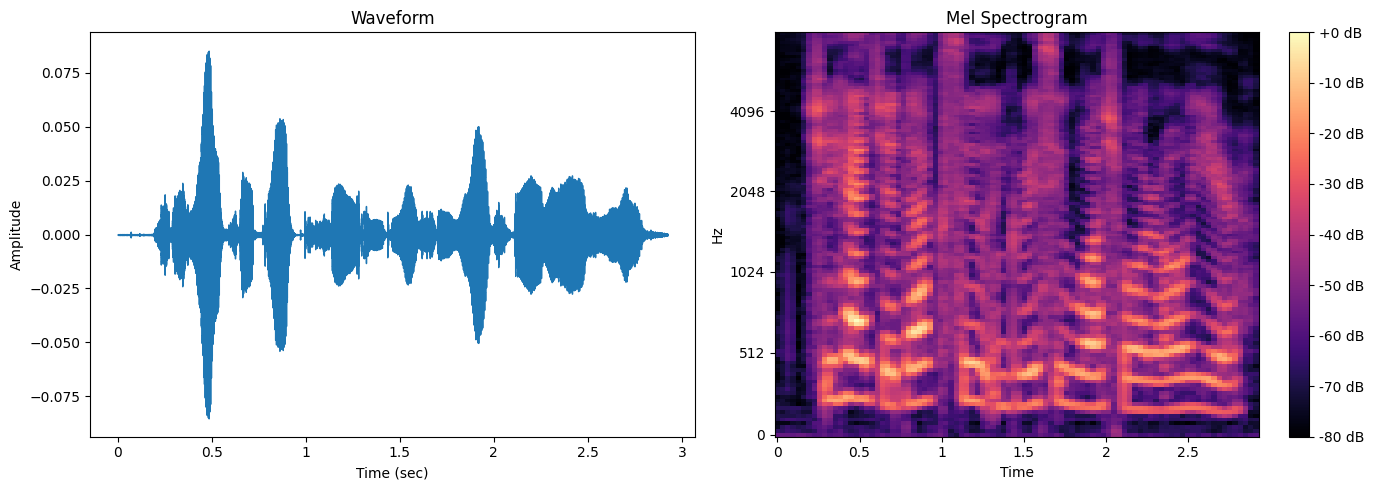

In [ ]:
import matplotlib.pyplot as plt
import librosa
import librosa.display

sample_audio = timit["train"][0]["audio"]["array"]
sr = timit["train"][0]["audio"]["sampling_rate"]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
librosa.display.waveshow(sample_audio, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
S = librosa.feature.melspectrogram(y=sample_audio, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

all_phonemes = []
for x in timit["train"]:
    all_phonemes.extend(x["phonetic_detail"]["utterance"])

phoneme_counts = Counter(all_phonemes)

print(f"Overall number of unique phonemes in train dataset: {len(phoneme_counts)}")
print("Top-10 most popular phonemes:")
for phn, count in phoneme_counts.most_common(10):
    print(f" - {phn}: {count} times")

print("\nTop-5 least popular:")
for phn, count in phoneme_counts.most_common()[-5:]:
    print(f" - {phn}: {count} times")

Overall number of unique phonemes in train dataset: 61
Top-10 most popular phonemes:
 - h#: 9240 times
 - ix: 8642 times
 - s: 7475 times
 - n: 7068 times
 - iy: 6953 times
 - tcl: 6644 times
 - r: 6539 times
 - kcl: 5859 times
 - l: 5801 times
 - ih: 5051 times

Top-5 least popular:
 - uh: 535 times
 - ax-h: 375 times
 - zh: 151 times
 - em: 124 times
 - eng: 38 times


Найчастіше в датасеті з'вляється фонем тиші (h#). Також в цьому топі найпопулярніших видно tcl і kcl - це closures (мілісекундні паузи, коли людина затримує дихання перед тим, як вимовити звуки "т" або "к"). Отже, величезна частина людської мови це насправді мікропаузи і тиша.

Ще один висновок з цієї статистика полягає в тому, що в нас сильний дисбаланс класів. Найпопулярніще слово зустрічається 9240 разів, а найменш популярне - всього 38 разів. Крім того, наявність 61 вузькоспеціалізованої мітки створює акустичну "надскладність". Відповідно до загальноприйнятого стандарту оцінки моделей на TIMIT (Lee & Hon, 1989), для коректного підрахунку метрики PER та стабілізації навчання, ми застосували мапінг 61 оригінальної фонеми у 39 базових фонематичних класів.

In [ ]:
# Key: original phoneme, Value: new phoneme (or None, if it should br ignored)
PHONEME_MAP = {
    'aa': 'aa', 'ae': 'ae', 'ah': 'ah', 'ao': 'aa', 'aw': 'aw', 'ax': 'ah', 'ax-h': 'ah', 'axr': 'er', 'ay': 'ay', 'b': 'b',
    'bcl': 'sil', 'ch': 'ch', 'd': 'd', 'dcl': 'sil', 'dh': 'dh', 'dx': 'dx', 'eh': 'eh', 'el': 'l', 'em': 'm', 'en': 'n',
    'eng': 'ng', 'epi': 'sil', 'er': 'er', 'ey': 'ey', 'f': 'f', 'g': 'g', 'gcl': 'sil', 'h#': 'sil', 'hh': 'hh', 'hv': 'hh',
    'ih': 'ih', 'ix': 'ih', 'iy': 'iy', 'jh': 'jh', 'k': 'k', 'kcl': 'sil', 'l': 'l', 'm': 'm', 'n': 'n', 'ng': 'ng',
    'nx': 'n', 'ow': 'ow', 'oy': 'oy', 'p': 'p', 'pau': 'sil', 'pcl': 'sil', 'q': 'sil', 'r': 'r', 's': 's', 'sh': 'sh',
    't': 't', 'tcl': 'sil', 'th': 'th', 'uh': 'uh', 'uw': 'uw', 'ux': 'uw', 'v': 'v', 'w': 'w', 'y': 'y', 'z': 'z', 'zh': 'sh'
}


unique_phonemes_39 = sorted(list(set(PHONEME_MAP.values())))
phoneme_to_id = {phn: i for i, phn in enumerate(unique_phonemes_39)}
id_to_phoneme = {i: phn for phn, i in phoneme_to_id.items()}

print(f"Number of unique phonemes: {len(unique_phonemes_39)}")
print("Unique phonemes list:", unique_phonemes_39)

Number of unique phonemes: 39
Unique phonemes list: ['aa', 'ae', 'ah', 'aw', 'ay', 'b', 'ch', 'd', 'dh', 'dx', 'eh', 'er', 'ey', 'f', 'g', 'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'r', 's', 'sh', 'sil', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z']


Оскільки ми використовуємо підхід на основі Cross-Entropy, нам потрібно кожному вектору ознак, який генерує модель, зіставити конкретний клас (фонему). Враховуючи, що Wav2Vec 2.0 має рецептивне поле та крок у 320 семплів, ми конвертували часові мітки початку та кінця кожної фонеми у відповідні індекси фреймів. Таким чином, задача розпізнавання мови звелася до задачі класифікації кожного окремого фрейму.

In [ ]:
import math

def create_frame_labels(starts, stops, phonemes, audio_length, stride=320):
    """
    Converts time lables of phonemes (in samples) into an array of classes for each frame
    """
    num_frames = math.ceil(audio_length / stride)

    # -100 - ignore_index
    labels = [-100] * num_frames

    for start, stop, phn in zip(starts, stops, phonemes):
        mapped_phn = PHONEME_MAP.get(phn, 'sil')

        phn_id = phoneme_to_id[mapped_phn]

        start_frame = start // stride
        stop_frame = stop // stride

        for frame_idx in range(start_frame, min(stop_frame + 1, num_frames)):
            labels[frame_idx] = phn_id

    return labels

In [ ]:
# Test
sample = timit["train"][0]
audio_array = sample["audio"]["array"]
starts = sample["phonetic_detail"]["start"]
stops = sample["phonetic_detail"]["stop"]
phns = sample["phonetic_detail"]["utterance"]

frame_labels = create_frame_labels(starts, stops, phns, len(audio_array))

print(f"Audio length (in samples): {len(audio_array)}")
print(f"Expected number of frames: {math.ceil(len(audio_array) / 320)}")
print(f"Number of generated lables: {len(frame_labels)}")
print(f"First 30 lables: {frame_labels[:30]}")

print("How it looks in text form (first 10 frames):", [id_to_phoneme[lbl] for lbl in frame_labels[:10]])

Audio length (in samples): 46797
Expected number of frames: 147
Number of generated lables: 147
First 30 lables: [30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 29, 29, 29, 29, 16, 16, 16, 15, 15, 15, 10, 10, 10, 10, 10, 10, 10, 30, 18, 18]
How it looks in text form (first 10 frames): ['sil', 'sil', 'sil', 'sil', 'sil', 'sil', 'sil', 'sil', 'sil', 'sh']


Тепер створюємо датасет

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TIMITDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        audio = sample["audio"]["array"]
        starts = sample["phonetic_detail"]["start"]
        stops = sample["phonetic_detail"]["stop"]
        phns = sample["phonetic_detail"]["utterance"]

        audio_tensor = torch.tensor(audio, dtype=torch.float32)

        labels = create_frame_labels(starts, stops, phns, len(audio))
        labels_tensor = torch.tensor(labels, dtype=torch.long)

        return {"audio": audio_tensor, "labels": labels_tensor}

In [ ]:
train_dataset = TIMITDataset(timit["train"])
test_dataset = TIMITDataset(timit["test"])

Функція для падінгу

In [ ]:
def collate_fn(batch):
    audios = [item["audio"] for item in batch]
    labels = [item["labels"] for item in batch]

    padded_audios = pad_sequence(audios, batch_first=True, padding_value=0.0)
    padded_labels = pad_sequence(labels, batch_first=True, padding_value=-100)

    return {"audio": padded_audios, "labels": padded_labels}

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

In [ ]:
# Test dataloader
batch = next(iter(train_loader))

print("Audio size (Batch Size, Sequence Length):", batch["audio"].shape)
print("Lables size (Batch Size, Number of Frames):", batch["labels"].shape)

Audio size (Batch Size, Sequence Length): torch.Size([4, 62260])
Lables size (Batch Size, Number of Frames): torch.Size([4, 195])


Для оптимізації процесу навчання ми реалізовали кастомний PyTorch Dataset та DataLoader. Оскільки аудіозаписи у датасеті TIMIT мають змінну тривалість, ми застосовали динамічний паддінг на рівні формування батчів за допомогою функції collate_fn. Аудіо-тензори доповнювалися нулями (0.0), а послідовності міток значенням -100 (ignore_index), що гарантує коректне обчислення Cross-Entropy Loss лише для фактичних фреймів, виключаючи згенерований паддінг

Тепер переходимо до моделі

In [ ]:
import torch.nn as nn
from transformers import Wav2Vec2Model

class PhonemeClassifier(nn.Module):
    def __init__(self, num_classes=39):
        super().__init__()

        print("Downloading the model Wav2Vec 2.0...")
        # only feature-extractor
        self.ssl_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

        # Freeze model parameters
        for param in self.ssl_model.parameters():
            param.requires_grad = False

        # Our classificator (input: 768, output: 39)
        self.classifier = nn.Linear(self.ssl_model.config.hidden_size, num_classes)

    def forward(self, audio):
        outputs = self.ssl_model(audio)
        hidden_states = outputs.last_hidden_state # [Batch, Frames, 768]
        logits = self.classifier(hidden_states) # [Batch, Frames, 39]

        return logits

In [ ]:
model = PhonemeClassifier(num_classes=39)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PhonemeClassifier(
  (ssl_model): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (enco

Test run

In [ ]:
test_audio = batch["audio"].to(device)
test_labels = batch["labels"].to(device)

model.eval()

with torch.no_grad():
    predictions = model(test_audio)

print("Size of input audio:", test_audio.shape)
print("Labels size:", test_labels.shape)
print("Logits size:", predictions.shape)

Size of input audio: torch.Size([4, 62260])
Labels size: torch.Size([4, 195])
Logits size: torch.Size([4, 194, 39])


Як baseline ми обрали facebook/wav2vec2-base. Відповідно до парадигми Linear Probing, ваги базової SSL-моделі були заморожені (requires_grad = False), що дозволило зберегти попередньо вивчені акустичні репрезентації та оптимізувати використання обчислювальних ресурсів. Класифікаційна "голова" являє собою лінійний шар (nn.Linear), який трансформує вихідний прихований стан моделі (розмірністю 768) у розподіл логітів для 39 фонематичних класів

Під час розробки пайплайну ми виявили незначну розбіжність у довжині послідовностей: кількість фреймів, згенерованих акустичною моделлю (Wav2Vec 2.0), на 1-3 фрейми менша за цільову розмітку. Це явище є наслідком зменшення розмірності на краях послідовності під час проходження через багатошарову CNN. Для синхронізації логітів та міток перед обчисленням функції втрат ми вирішили застосувати truncation по мінімальній довжині в кожному батчі.

In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
epochs = 10

print("Starting training\n")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        audios = batch["audio"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(audios)

        # Frames leveling
        min_len = min(logits.shape[1], labels.shape[1])
        logits = logits[:, :min_len, :]
        labels = labels[:, :min_len]

        logits_flat = logits.reshape(-1, 39)
        labels_flat = labels.reshape(-1)

        loss = loss_fn(logits_flat, labels_flat)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} is complete! Average Loss: {avg_loss:.4f}\n")

print("The training process is finished")

Starting training

Epoch 1/10 | Batch 0/1155 | Loss: 3.7451
Epoch 1/10 | Batch 50/1155 | Loss: 3.3962
Epoch 1/10 | Batch 100/1155 | Loss: 3.1627
Epoch 1/10 | Batch 150/1155 | Loss: 2.8917
Epoch 1/10 | Batch 200/1155 | Loss: 3.0025
Epoch 1/10 | Batch 250/1155 | Loss: 2.8592
Epoch 1/10 | Batch 300/1155 | Loss: 2.7919
Epoch 1/10 | Batch 350/1155 | Loss: 2.8419
Epoch 1/10 | Batch 400/1155 | Loss: 2.7447
Epoch 1/10 | Batch 450/1155 | Loss: 2.6653
Epoch 1/10 | Batch 500/1155 | Loss: 2.7069
Epoch 1/10 | Batch 550/1155 | Loss: 2.6271
Epoch 1/10 | Batch 600/1155 | Loss: 2.5642
Epoch 1/10 | Batch 650/1155 | Loss: 2.5242
Epoch 1/10 | Batch 700/1155 | Loss: 2.4746
Epoch 1/10 | Batch 750/1155 | Loss: 2.4952
Epoch 1/10 | Batch 800/1155 | Loss: 2.4740
Epoch 1/10 | Batch 850/1155 | Loss: 2.2756
Epoch 1/10 | Batch 900/1155 | Loss: 2.6410
Epoch 1/10 | Batch 950/1155 | Loss: 2.3010
Epoch 1/10 | Batch 1000/1155 | Loss: 2.2733
Epoch 1/10 | Batch 1050/1155 | Loss: 2.3393
Epoch 1/10 | Batch 1100/1155 | Loss:

Тесстування і метрики

In [ ]:
!pip install jiwer

In [ ]:
import torch
import jiwer
from itertools import groupby

model.eval()

all_refs = []
all_hyps = [] # model predictions

print("Starting testing")

with torch.no_grad():
    for batch in test_loader:
        audios = batch["audio"].to(device)
        labels = batch["labels"].to(device)

        logits = model(audios)

        preds = torch.argmax(logits, dim=-1)

        min_len = min(preds.shape[1], labels.shape[1])
        preds = preds[:, :min_len]
        labels = labels[:, :min_len]

        for i in range(labels.size(0)):
            valid_indices = labels[i] != -100

            true_ids = labels[i][valid_indices].cpu().tolist()
            pred_ids = preds[i][valid_indices].cpu().tolist()

            true_phns = [id_to_phoneme[idx] for idx in true_ids]
            pred_phns = [id_to_phoneme[idx] for idx in pred_ids]

            # Get rid of duplicates
            true_collapsed = [k for k, g in groupby(true_phns)]
            pred_collapsed = [k for k, g in groupby(pred_phns)]

            all_refs.append(" ".join(true_collapsed))
            all_hyps.append(" ".join(pred_collapsed))

per = jiwer.wer(all_refs, all_hyps)

print("\nFinished testing")
print(f"Phoneme Error Rate (PER): {per * 100:.2f}%")

print("\nExample of model predictions:")
print(f"Correct: {all_refs[0]}")
print(f"Prediction:   {all_hyps[0]}")

Starting testing

Finished testing
Phoneme Error Rate (PER): 68.86%

Example of model predictions:
Correct: sil sh iy hh ae sil d y er sil d aa r sil k s uw dx ih ng sil g r iy s iy w aa sh sil w aa dx er sil aa l y iy er sil
Prediction:   sil sh iy sil hh aa sil d sil er sil d aa r er sil s uw sil d ih n sil g sil r er iy sh s sil iy aa sil w aa sil sh sil w aa dx er aa l iy y iy uw er sil


Baseline з використанням замороженого екстрактора ознак Wav2Vec 2.0 та пофреймової функції втрат Cross-Entropy показала результат PER = 68.86%. Аналіз прогнозів свідчить, що класифікатор успішно вивчив загальні фонетичні патерни, однак метрика значно погіршується через велику кількість помилок типу "Вставка". Це явище зумовлене нестабільністю прогнозів на рівні окремих фреймів та відсутністю механізму глобального вирівнювання послідовностей. Цей результат підтверджує необхідність переходу до більш просунутих методів вирівнювання, таких як CTC Loss, або Fine-tuning параметрів базової моделі.

У першій частині ми використовували Cross-Entropy Loss. Проблема в тому, що CE вимагає точного вирівнювання: для кожного фрейму аудіо ми мусимо знати яка саме фонема там звучить. Через це модель генерувала купу зайвих фонем і PER був 68%.

CTC (Connectionist Temporal Classification) вирішує це інакше — ми просто даємо моделі список фонем у правильному порядку (наприклад, `sil sh iy hh`), і вона сама вчиться розібратись коли саме кожна фонема починається і закінчується.

**Як це працює**

**1.** CTC додає спеціальний символ `<blank>` (індекс 0). Він означає "на цьому фреймі нічого конкретного не відбувається". Це дозволяє моделі "мовчати" між фонемами або розділяти однакові фонеми поспіль.

**2.** Модель на кожному фреймі видає якийсь символ. Наприклад: `s s <blank> h h h`. Щоб отримати фінальну відповідь, ми: спочатку видаляємо дублікати → `s <blank> h`, потім видаляємо blank'и → `s h`. Це і є функція колапсування.

**3.** Модель вчиться так, щоб сума ймовірностей усіх можливих послідовностей фреймів, які колапсуються в правильну відповідь, була максимальною. Таких послідовностей може бути дуже багато, тому їх не перебирають напряму — використовують динамічне програмування (forward-backward алгоритм), яке рахує це ефективно.

**4.** `L_CTC = -log p(правильна відповідь | аудіо)` — просто мінімізуємо від'ємний логарифм ймовірності правильної відповіді.

**5.** Після навчання для отримання відповіді беремо найбільш ймовірний символ на кожному фреймі, і застосовуємо колапсування. Це називається greedy decoding — швидко і просто.

У першій частині Dataset був складнішим — для кожного фрейму аудіо треба було знати точну фонему. Ми брали часові мітки початку/кінця кожної фонеми і перетворювали їх у масив міток розміром "кількість фреймів".

Для CTC це не потрібно. Нам достатньо просто знати які фонеми звучать у записі і в якому порядку. Наприклад: `['sil', 'sh', 'iy', 'hh', 'ae']`. Без прив'язки до часу.

Тому Dataset став простішим: беремо аудіо, беремо список фонем, конвертуємо фонеми в числа — готово.

DataLoader теж трохи змінився. CTCLoss в PyTorch має специфічну вимогу: мітки всіх записів у батчі треба склеїти в один довгий 1D тензор, і окремо передати довжини кожної послідовності. Тому collate\_fn тепер повертає чотири речі: аудіо (з паддінгом), склеєні мітки, довжини аудіо і довжини міток.

In [ ]:
!pip install torch

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from itertools import groupby


class TIMITDatasetCTC(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        audio = sample['audio']['array']
        phonemes_raw = sample['phonetic_detail']['utterance']

        # map 61 -> 39 phonemes and collapse consecutive duplicates
        mapped = [PHONEME_MAP.get(p, 'sil') for p in phonemes_raw]
        collapsed = [k for k, _ in groupby(mapped)]
        label_ids = [phoneme_to_id[p] for p in collapsed]

        return {
            'audio': torch.tensor(audio, dtype=torch.float32),
            'labels': torch.tensor(label_ids, dtype=torch.long),
        }


def ctc_collate_fn(batch):
    audios = [item['audio'] for item in batch]
    labels = [item['labels'] for item in batch]

    padded_audios = pad_sequence(audios, batch_first=True, padding_value=0.0)
    audio_lengths = torch.tensor([len(a) for a in audios], dtype=torch.long)
    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    labels_concat = torch.cat(labels)  # CTCLoss expects a flat 1D tensor

    return {
        'audio': padded_audios,
        'labels': labels_concat,
        'audio_lengths': audio_lengths,
        'label_lengths': label_lengths,
    }


train_dataset_ctc = TIMITDatasetCTC(timit['train'])
test_dataset_ctc  = TIMITDatasetCTC(timit['test'])

train_loader_ctc = DataLoader(train_dataset_ctc, batch_size=2, shuffle=True,  collate_fn=ctc_collate_fn)
test_loader_ctc  = DataLoader(test_dataset_ctc,  batch_size=2, shuffle=False, collate_fn=ctc_collate_fn)

batch = next(iter(train_loader_ctc))
print('audio:', batch['audio'].shape)
print('labels:', batch['labels'].shape)
print('audio_lengths:', batch['audio_lengths'])
print('label_lengths:', batch['label_lengths'])

audio: torch.Size([2, 55706])
labels: torch.Size([86]) (конкатенований 1D)
audio_lengths: tensor([55706, 50074])
label_lengths: tensor([41, 45])


Ми зробили одну універсальну архітектуру, яка працює з будь-якою SSL-моделлю з HuggingFace — wav2vec2, HuBERT, WavLM — без змін у коді. Просто передаєш назву моделі рядком.

Модель складається з двох частин. Перша — це SSL-енкодер, який перетворює сире аудіо у послідовність векторів (768-розмірних для base моделей). Друга — лінійний класифікатор, який бере кожен такий вектор і видає розподіл по 40 класах (39 фонем + blank).

Ваги SSL-енкодера заморожені — ми не навчаємо його заново, а просто використовуємо готові репрезентації. Навчається тільки лінійний шар зверху. Це називається linear probing і дозволяє швидко порівняти якість різних SSL-моделей без великих витрат на обчислення.

Також модель підтримує вибір шару. За замовчуванням використовується `last_hidden_state` — вихід останнього Transformer-шару. Але можна передати `layer_index` і отримати вихід будь-якого проміжного шару. Для цього при завантаженні моделі ми передаємо `output_hidden_states=True`, і тоді `outputs.hidden_states` містить виходи всіх шарів у вигляді кортежу. Індекс зсунутий на 1 (`hidden_states[layer_index + 1]`), бо нульовий елемент — це embedding layer до Transformer-блоків.

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

NUM_CLASSES = 40


class SSLPhonemeClassifierCTC(nn.Module):
    def __init__(self, model_name, num_classes=40, layer_index=None, freeze_encoder=True):
        super().__init__()
        self.layer_index = layer_index

        # output_hidden_states=True to access intermediate layers
        self.ssl_model = AutoModel.from_pretrained(model_name, output_hidden_states=True)

        if freeze_encoder:
            for param in self.ssl_model.parameters():
                param.requires_grad = False

        hidden_size = self.ssl_model.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, audio, attention_mask=None):
        outputs = self.ssl_model(audio, attention_mask=attention_mask)

        if self.layer_index is None or self.layer_index == -1:
            hidden = outputs.last_hidden_state
        else:
            # index +1 to skip the embedding layer
            hidden = outputs.hidden_states[self.layer_index + 1]

        return self.classifier(hidden)  # [B, T, num_classes]


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Пристрій: {device}')

test_model = SSLPhonemeClassifierCTC('facebook/wav2vec2-base').to(device)
dummy = torch.randn(2, 16000).to(device)
with torch.no_grad():
    out = test_model(dummy)
print(f'Вхід: {dummy.shape} -> Вихід {out.shape}')
del test_model


Пристрій: cuda
Завантаження facebook/wav2vec2-base...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Ваги facebook/wav2vec2-base заморожено
  hidden_size=768, num_classes=40

Вхід: torch.Size([2, 16000]) -> Вихід (logits): torch.Size([2, 49, 40])  [batch, frames, classes]


PyTorch CTCLoss приймає не просто логіти, а `log_softmax` від логітів. Це технічна вимога для числової стабільності — без цього градієнти можуть переповнитись.

Друга неочевидна річ — довжини. CTCLoss потребує не довжину аудіо в семплах, а довжину послідовності після CNN-енкодера. Тобто скільки фреймів видала модель для цього запису.

Проблема в тому, що в батчі всі аудіо доповнені паддінгом до однакової довжини. Якщо передати CTCLoss однакові довжини для всіх — вона думатиме що паддінг це теж реальне аудіо і буде рахувати loss неправильно. Тому ми окремо рахуємо реальну довжину кожного запису після CNN.

CNN-енкодер у wav2vec2/HuBERT/WavLM має 7 шарів зі stride `[5, 2, 2, 2, 2, 2, 2]` і kernel `[10, 3, 3, 3, 3, 2, 2]`. Для кожного шару довжина рахується як `(length - kernel) // stride + 1`. Загальний stride виходить ~320 — тобто кожні 320 семплів перетворюються в 1 фрейм. Для аудіо 16000 семплів (1 секунда) це приблизно 49 фреймів.

In [ ]:
import torch
import math


def compute_encoder_output_length(audio_length):
    # CNN config for wav2vec2-base / HuBERT-base / WavLM-base
    strides = [5, 2, 2, 2, 2, 2, 2]
    kernels = [10, 3, 3, 3, 3, 2, 2]
    length = audio_length
    for kernel, stride in zip(kernels, strides):
        length = (length - kernel) // stride + 1
    return max(1, length)


def get_input_lengths(audio_lengths):
    # convert raw audio lengths to encoder output lengths for CTCLoss
    return torch.tensor(
        [compute_encoder_output_length(l.item()) for l in audio_lengths],
        dtype=torch.long
    )


test_lengths = torch.tensor([16000, 32000, 48000])
enc_lengths = get_input_lengths(test_lengths)
print('Аудіо тривалості (семпли): ', test_lengths.tolist())
print('Відповідні encoder довжини (фрейми): [', enc_lengths.tolist())
print(f'Загальний stride ≈ {16000 / enc_lengths[0].item():.1f} samples/frame')

Аудіо тривалості (семпли): [16000, 32000, 48000]
Відповідні encoder довжини (фрейми): [49, 99, 149]
Загальний stride ≈ 16000 / 49 = 326.5 семплів/фрейм


Функція `train_one_epoch` проходить по всіх батчах, рахує CTCLoss і оновлює ваги класифікатора. Є одна важлива деталь — ми додали gradient clipping (`max_norm=1.0`). CTC на початку навчання може давати дуже великі градієнти, і без кліпінгу ваги можуть "вибухнути". Також пропускаємо батчи де loss вийшов `nan` або `inf` — це може статись якщо мітки довші за вихід енкодера.

Функція `greedy_ctc_decode` — це декодування після навчання. Беремо argmax на кожному фреймі, видаляємо дублікати сусідніх символів, видаляємо blank. Наприклад `s s <blank> h h` → `s <blank> h` → `s h`.

Функція `evaluate_per` рахує PER на тестовій вибірці. Тут є одна хитрість з тим як ми зберігаємо мітки в батчі — вони склеєні в один 1D тензор, тому при оцінці треба розрізати його назад по окремих записах використовуючи `label_lengths`.

Функція `train_and_evaluate` — це головна обгортка, яка приймає назву моделі, індекс шару та кількість епох, запускає повний цикл навчання і повертає словник з результатами. Після завершення явно видаляємо модель і чистимо GPU пам'ять через `gc.collect()` і `torch.cuda.empty_cache()` — це важливо щоб runtime не падав при запуску наступного експерименту.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import jiwer
import gc
from itertools import groupby


def train_one_epoch(model, loader, optimizer, ctc_loss_fn, device):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch_idx, batch in enumerate(loader):
        audios        = batch['audio'].to(device)
        labels        = batch['labels'].to(device)
        audio_lengths = batch['audio_lengths']
        label_lengths = batch['label_lengths']

        optimizer.zero_grad()
        logits = model(audios)

        # CTCLoss expects [T, B, C] and log_softmax
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1).transpose(0, 1)

        input_lengths = get_input_lengths(audio_lengths).to(device)
        input_lengths = input_lengths.clamp(max=log_probs.shape[0])

        loss = ctc_loss_fn(log_probs, labels, input_lengths, label_lengths.to(device))

        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1

        if batch_idx % 100 == 0:
            print(f'  Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.4f}')

    return total_loss / max(n_batches, 1)


def greedy_ctc_decode(logits):
    preds = torch.argmax(logits, dim=-1)
    decoded_batch = []
    for seq in preds:
        collapsed = [k for k, _ in groupby(seq.cpu().tolist())]
        decoded_batch.append([x for x in collapsed if x != BLANK_IDX])
    return decoded_batch


@torch.no_grad()
def evaluate_per(model, loader, device):
    model.eval()
    all_refs, all_hyps = [], []

    for batch in loader:
        audios        = batch['audio'].to(device)
        labels_flat   = batch['labels']
        label_lengths = batch['label_lengths']

        decoded = greedy_ctc_decode(model(audios))

        # labels are concatenated into 1D — split them back per sample
        offset = 0
        for i, ll in enumerate(label_lengths):
            true_ids = labels_flat[offset: offset + ll.item()].tolist()
            offset += ll.item()

            true_phns = [id_to_phoneme[idx] for idx in true_ids]
            pred_phns = [id_to_phoneme[idx] for idx in decoded[i] if idx in id_to_phoneme]

            all_refs.append(' '.join(true_phns))
            all_hyps.append(' '.join(pred_phns) if pred_phns else '<blank>')

    return jiwer.wer(all_refs, all_hyps) * 100, all_refs, all_hyps


def train_and_evaluate(model_name, layer_index=None, freeze_encoder=True, epochs=5, lr=1e-4, tag=''):
    run_name = tag or f'{model_name.split("/")[-1]}_layer_{layer_index}'
    print(f'\n{"="*60}\n{run_name}\n{"="*60}')

    model = SSLPhonemeClassifierCTC(
        model_name, num_classes=NUM_CLASSES,
        layer_index=layer_index,
        freeze_encoder=freeze_encoder
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    ctc_loss_fn = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)

    for epoch in range(epochs):
        avg_loss = train_one_epoch(model, train_loader_ctc, optimizer, ctc_loss_fn, device)
        print(f'Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.4f}')

    per, refs, hyps = evaluate_per(model, test_loader_ctc, device)
    print(f'\nPER = {per:.2f}%')
    print(f'REF: {refs[0]}')
    print(f'HYP: {hyps[0]}')

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return {'run': run_name, 'model': model_name, 'layer': layer_index,
            'freeze': freeze_encoder, 'per': per}


print('Функції навчання та оцінки готові.')

Функції навчання та оцінки готові.


wav2vec2 + CTC

Перший експеримент майже ідентичний до baseline з першої частини — та сама модель wav2vec2-base, ті самі заморожені ваги, той самий last_hidden_state. Єдина різниця — замість CE Loss використовуємо CTC.

Це дозволяє нам чисто порівняти два підходи і побачити скільки дає сам перехід на CTC, без зміни моделі. Результат — PER впав з 68% до 60.6%. Покращення є, але не драматичне. Це логічно — wav2vec2 не навчався передбачати фонетичні одиниці, тому його репрезентації просто не дуже підходять для цієї задачі, навіть з кращою функцією втрат.

In [ ]:
BLANK_IDX = 0

result_w2v2_last = train_and_evaluate(
    model_name='facebook/wav2vec2-base',
    layer_index=None,
    freeze_encoder=True,
    epochs=3,
    tag='wav2vec2-base_CTC_last'
)
print(f'РЕЗУЛЬТАТ wav2vec2 CTC: PER = {result_w2v2_last["per"]:.2f}%')


Запуск: wav2vec2-base_CTC_last
  model=facebook/wav2vec2-base, layer=None, freeze=True
Завантаження facebook/wav2vec2-base...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Ваги facebook/wav2vec2-base заморожено
  hidden_size=768, num_classes=40
  Batch 0/2310 | Loss: 12.6759
  Batch 100/2310 | Loss: 7.4120
  Batch 200/2310 | Loss: 4.2305
  Batch 300/2310 | Loss: 2.9236
  Batch 400/2310 | Loss: 3.0195
  Batch 500/2310 | Loss: 2.8696
  Batch 600/2310 | Loss: 3.5467
  Batch 700/2310 | Loss: 3.3553
  Batch 800/2310 | Loss: 3.0013
  Batch 900/2310 | Loss: 2.7557
  Batch 1000/2310 | Loss: 3.2746
  Batch 1100/2310 | Loss: 3.0795
  Batch 1200/2310 | Loss: 2.6958
  Batch 1300/2310 | Loss: 2.9679
  Batch 1400/2310 | Loss: 2.9155
  Batch 1500/2310 | Loss: 2.8506
  Batch 1600/2310 | Loss: 2.8092
  Batch 1700/2310 | Loss: 2.7350
  Batch 1800/2310 | Loss: 2.8029
  Batch 1900/2310 | Loss: 2.7154
  Batch 2000/2310 | Loss: 2.8473
  Batch 2100/2310 | Loss: 2.6129
  Batch 2200/2310 | Loss: 2.3351
  Batch 2300/2310 | Loss: 1.9911

Epoch 1/3 | Avg Loss: 3.3120
  Batch 0/2310 | Loss: 2.4815
  Batch 100/2310 | Loss: 2.5522
  Batch 200/2310 | Loss: 2.3999
  Batch 300/2310 | L

HuBERT + CTC

HuBERT відрізняється від wav2vec2 способом навчання. wav2vec2 навчається контрастно — вчиться відрізняти правильний квантизований вектор від набору випадкових "відволікань". HuBERT навчається інакше — для замаскованих фреймів він передбачає до якого кластера належить цей фрейм. Кластери будуються заздалегідь через k-means на MFCC або на виходах попередньої ітерації моделі.

Через це HuBERT формує репрезентації які набагато більше схожі на фонетичні одиниці — він буквально навчався розрізняти акустичні кластери. Тому ми очікували що linear probing поверх HuBERT дасть значно кращий PER ніж wav2vec2.

Результат підтвердив це — PER впав до 21.9%. Це більш ніж утричі краще ніж baseline і значно краще ніж wav2vec2 + CTC. Основний висновок: архітектура і спосіб pretraining SSL-моделі важливіші ніж вибір функції втрат.

In [ ]:
result_hubert_last = train_and_evaluate(
    model_name='facebook/hubert-base-ls960',
    layer_index=None,
    freeze_encoder=True,
    epochs=3,
    tag='hubert-base_CTC_last'
)
print(f'РЕЗУЛЬТАТ HuBERT CTC: PER = {result_hubert_last["per"]:.2f}%')


Запуск: hubert-base_CTC_last
  model=facebook/hubert-base-ls960, layer=None, freeze=True
Завантаження facebook/hubert-base-ls960...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

  Ваги facebook/hubert-base-ls960 заморожено
  hidden_size=768, num_classes=40
  Batch 0/2310 | Loss: 13.2287
  Batch 100/2310 | Loss: 9.4380
  Batch 200/2310 | Loss: 7.8224
  Batch 300/2310 | Loss: 8.5745
  Batch 400/2310 | Loss: 4.3982
  Batch 500/2310 | Loss: 4.2842
  Batch 600/2310 | Loss: 3.2325
  Batch 700/2310 | Loss: 2.7617
  Batch 800/2310 | Loss: 2.3777
  Batch 900/2310 | Loss: 2.0441
  Batch 1000/2310 | Loss: 1.9577
  Batch 1100/2310 | Loss: 1.6429
  Batch 1200/2310 | Loss: 1.6566
  Batch 1300/2310 | Loss: 1.2647
  Batch 1400/2310 | Loss: 4.4664
  Batch 1500/2310 | Loss: 0.9628
  Batch 1600/2310 | Loss: 1.3288
  Batch 1700/2310 | Loss: 1.2385
  Batch 1800/2310 | Loss: 1.3826
  Batch 1900/2310 | Loss: 1.0298
  Batch 2000/2310 | Loss: 1.0772
  Batch 2100/2310 | Loss: 1.1393
  Batch 2200/2310 | Loss: 0.8668
  Batch 2300/2310 | Loss: 3.2799

Epoch 1/3 | Avg Loss: 3.2552
  Batch 0/2310 | Loss: 0.6422
  Batch 100/2310 | Loss: 0.8941
  Batch 200/2310 | Loss: 0.6196
  Batch 300/2310

WavLM + CTC

WavLM будується поверх ідей HuBERT і додає одну річ — denoising. Під час навчання до аудіо штучно додається шум або накладаються інші фрейми, і модель вчиться передбачати оригінальні чисті фрейми. Через це WavLM формує більш стійкі репрезентації в умовах шуму.

TIMIT — студійний датасет, майже без фонового шуму. Тому великої переваги WavLM над HuBERT ми не очікували. Але результат виявився кращим — PER 19.0% проти 21.9% у HuBERT. Невелика але стабільна різниця.

Можливе пояснення: denoising під час pretraining змушує модель будувати більш інваріантні та узагальнені репрезентації — не лише стійкі до шуму, але й загалом більш інформативні для фонетичних задач. Тобто користь від denoising виявляється ширшою ніж просто робота з зашумленим аудіо.

In [ ]:
result_wavlm_last = train_and_evaluate(
    model_name='microsoft/wavlm-base',
    layer_index=None,
    freeze_encoder=True,
    epochs=3,
    tag='wavlm-base_CTC_last'
)
print(f'РЕЗУЛЬТАТ WavLM CTC: PER = {result_wavlm_last["per"]:.2f}%')

який шар HuBERT найкращий для фонем

У попередніх експериментах ми завжди брали `last_hidden_state` — вихід останнього шару. Але це не обов'язково найкращий вибір для кожної задачі.

Стаття HuBERT показала що різні шари зберігають різну інформацію. Ранні шари (1-4) містять низькорівневі акустичні ознаки — гучність, pitch, форма хвилі. Середні шари (5-8) містять фонетичну інформацію — саме те що нам потрібно. Пізні шари (9-12) більше орієнтовані на семантику і контекст — корисно для розпізнавання слів, але не фонем.

Тому гіпотеза була: середній шар (~6) дасть найкращий PER.

Результати частково підтвердили це — шар 3 дав найгірший результат (43.6%), шар 6 різко покращився (24.8%), шар 9 майже не змінився (25.4%). Але найкращим виявився last(12) з PER 22.0%, а не шар 6 як очікувалось.

Можливе пояснення цього відхилення від гіпотези: ми навчали лише 3 епохи. За такий короткий час лінійний класифікатор міг не встигнути повністю "витягнути" фонетичну інформацію з проміжних шарів, тоді як останній шар вже містить більш готові до класифікації репрезентації і потребує менше навчання зверху.

In [ ]:
layer_results = []

for layer_idx in [2, 5, 8, None]:
    label = f'layer_{layer_idx + 1}' if layer_idx is not None else 'last(12)'
    r = train_and_evaluate(
        model_name='facebook/hubert-base-ls960',
        layer_index=layer_idx,
        freeze_encoder=True,
        epochs=3,
        tag=f'hubert_CTC_{label}'
    )
    layer_results.append(r)
    print(f'РЕЗУЛЬТАТ {r["run"]}: PER = {r["per"]:.2f}%')

Зводимо всі результати в одну таблицю щоб порівняти. За baseline беремо результат першої частини — wav2vec2 + CE Loss з PER 68.04%.

In [ ]:
import pandas as pd

baseline = {'run': 'wav2vec2-base_CE_last (Baseline)', 'model': 'facebook/wav2vec2-base',
            'layer': 'last', 'loss': 'CE', 'per': 68.04}

all_results = [
    baseline,
    {**result_w2v2_last,  'loss': 'CTC', 'layer': 'last'},
    {**result_hubert_last, 'loss': 'CTC', 'layer': 'last'},
    {**result_wavlm_last,  'loss': 'CTC', 'layer': 'last'},
    *[{**r, 'loss': 'CTC'} for r in layer_results],
]

df = pd.DataFrame([
    {
        'Запуск': r['run'],
        'SSL-модель': r['model'].split('/')[-1],
        'Шар': r.get('layer', 'last'),
        'Loss': r.get('loss', 'CTC'),
        'PER (%)': f"{r['per']:.2f}"
    }
    for r in all_results
])

print('\n=== ПОРІВНЯЛЬНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ ===')
print(df.to_string(index=False))

best = min(all_results[1:], key=lambda x: x['per'])
print(f"\n>>> Найкращий результат: {best['run']} — PER = {best['per']:.2f}%")

Будуємо два графіки. Перший показує як змінюється PER залежно від моделі — видно що перехід від wav2vec2 до HuBERT і WavLM дає набагато більший приріст ніж перехід з CE на CTC в рамках однієї моделі. Другий показує як PER змінюється по шарах HuBERT — видно різкий стрибок між шаром 3 і шаром 6, і поступове покращення далі аж до останнього шару.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

models_comparison = [
    ('Baseline\nwav2vec2 CE', 68.04),
    ('wav2vec2\nCTC', result_w2v2_last['per']),
    ('HuBERT\nCTC', result_hubert_last['per']),
    ('WavLM\nCTC', result_wavlm_last['per']),
]
names, pers = zip(*models_comparison)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

bars = axes[0].bar(names, pers, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('PER (%)', fontsize=12)
axes[0].set_title('Порівняння SSL-моделей\n(last_hidden_state)', fontsize=13)
axes[0].set_ylim(0, max(pers) * 1.2)
for bar, per in zip(bars, pers):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{per:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].axhline(68.04, color='red', linestyle='--', alpha=0.5, label='Baseline (CE)')
axes[0].legend()

layer_names = [r['run'].split('_')[-1] for r in layer_results]
layer_pers  = [r['per'] for r in layer_results]

axes[1].plot(layer_names, layer_pers, marker='o', color='#2ecc71',
             linewidth=2, markersize=8)
axes[1].set_ylabel('PER (%)', fontsize=12)
axes[1].set_title('PER за шарами HuBERT\n(середні шари очікувано кращі)', fontsize=13)
axes[1].set_ylim(0, max(layer_pers) * 1.2)
for x, y in zip(layer_names, layer_pers):
    axes[1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Графік збережено як results_comparison.png')

**CE vs CTC.** Baseline з CE Loss давав PER 68% через велику кількість помилок типу Insertion — модель бачила нестабільний фрейм і вставляла зайву фонему. CTC вирішує це через blank токен — замість того щоб щось вигадувати на кожному фреймі, модель може просто "помовчати". Перехід на CTC при тій самій моделі дав -7.4% PER.

**Яка SSL-модель краща.** Найбільший вплив на результат мала не функція втрат, а сама SSL-модель. wav2vec2 навчався відрізняти правильний вектор від випадкових — корисно, але не прямо пов'язано з фонемами. HuBERT навчався передбачати акустичні кластери — його репрезентації вже схожі на фонетичні одиниці, тому лінійний класифікатор зверху справляється набагато краще. WavLM додав denoising і виявився найкращим навіть на чистому TIMIT — мабуть тому що denoising змушує модель будувати більш загальні та інваріантні репрезентації.

**Шари HuBERT.** Гіпотеза з паперу підтвердилась частково. Ранній шар 3 справді найгірший (43.6%) — він ще не сформував фонетичні репрезентації. Шар 6 різко кращий (24.8%) що підтверджує ідею про "фонетичні середні шари". Але останній шар виявився найкращим (22.0%), що суперечить очікуванням. Швидше за все це артефакт малої кількості епох — за 3 епохи класифікатор просто не встиг повністю використати інформацію з проміжних шарів.